In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')


In [ ]:
BG        = '#0D0D0D'
SURFACE   = '#141414'
SURFACE2  = '#1C1C1C'
BORDER    = '#2A2A2A'
TEXT      = '#F0EDE6'
MUTED     = '#7A7773'
RED       = '#C8382A'
RED_LIGHT = '#E05040'
AMBER     = '#C8923A'
TEAL      = '#2E9E7A'
BLUE      = '#4A7FC4'
GREEN     = '#4E8C3A'


In [ ]:
plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    BORDER,
    'axes.labelcolor':   MUTED,
    'axes.titlecolor':   TEXT,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.spines.bottom':False,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'grid.color':        BORDER,
    'grid.linewidth':    0.5,
    'text.color':        TEXT,
    'font.family':       'DejaVu Sans',
    'font.size':         9,
    'legend.facecolor':  SURFACE2,
    'legend.edgecolor':  BORDER,
    'legend.labelcolor': TEXT,
    'figure.dpi':        150,
})

In [ ]:
def subtitle(ax, text):
    ax.set_title(text, fontsize=8, color=MUTED, loc='left', pad=4)

def title(ax, text):
    ax.text(0, 1.08, text, transform=ax.transAxes,
            fontsize=10, fontweight='bold', color=TEXT, va='bottom')

def save(fig, name):
    fig.savefig(f'/home/claude/{name}', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.close(fig)
    print(f'  ✓  Saved {name}')

print()
print('=' * 62)
print('  FEMICIDE IN KENYA — PYTHON ANALYSIS')
print('=' * 62)


  FEMICIDE IN KENYA — PYTHON ANALYSIS


In [ ]:
print('\n[1/6]  LOADING DATA')

df_raw = pd.read_csv('/content/sample_data/femicide_data.csv')
print(f'       Loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')


[1/6]  LOADING DATA
       Loaded: 507 rows × 21 columns


In [ ]:
print('\n[2/6]  CLEANING DATA')

df = df_raw.copy()

# ── 2.1  Rename awkward column ────────────────────────────────────────────────
df.rename(columns={'court_date_(first_appearance)': 'court_date'}, inplace=True)

# ── 2.2  Strip whitespace from all text columns ───────────────────────────────
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

# ── 2.3  Normalise: type_of_femicide ─────────────────────────────────────────
df['type_of_femicide'] = (df['type_of_femicide']
    .str.lower().str.strip()
    .replace({'intimate': 'Intimate', 'non-intimate': 'Non-Intimate',
              'non intimate': 'Non-Intimate'}))




[2/6]  CLEANING DATA


In [ ]:
# ── 2.4  Normalise: suspect_relationship ─────────────────────────────────────
rel_map = {
    'husband':                      'Husband',
    'Husband':                      'Husband',
    'boyfriend':                    'Boyfriend',
    'Boyfriend':                    'Boyfriend',
    'ex-husband':                   'Ex-Husband',
    'Ex-husband':                   'Ex-Husband',
    'ex-boyfriend':                 'Ex-Boyfriend',
    'Ex-boyfriend':                 'Ex-Boyfriend',
    'family member':                'Family Member',
    'Family member':                'Family Member',
    'friend/known to victim':       'Friend/Known',
    'Friend/known to victim':       'Friend/Known',
    'stranger/unknown relationship':'Stranger/Unknown',
    'Stranger/unknown relationship':'Stranger/Unknown',
}
df['suspect_relationship'] = df['suspect_relationship'].replace(rel_map)

In [ ]:
# ── 2.5  Normalise: mode_of_killing ──────────────────────────────────────────
df['mode_of_killing'] = (df['mode_of_killing']
    .str.lower().str.strip()
    .replace({
        'stabbed':         'Stabbed',
        'blunt force':     'Blunt Force',
        'hacked':          'Hacked',
        'strangled':       'Strangled',
        'shot':            'Shot',
        'sexual assault':  'Sexual Assault',
        'burned':          'Burned',
        'other':           'Other',
    }))

In [ ]:
# ── 2.6  Normalise: murder_scene ─────────────────────────────────────────────
df['murder_scene'] = (df['murder_scene']
    .str.lower().str.strip()
    .replace({
        'home':         'Home',
        'public space': 'Public Space',
        'school':       'School',
        'workplace':    'Workplace',
        'other':        'Other',
    }))

In [ ]:
# ── 2.7  Normalise: verdict ───────────────────────────────────────────────────
df['verdict'] = (df['verdict']
    .str.lower().str.strip()
    .replace({
        'guilty':     'Guilty',
        'not guilty': 'Not Guilty',
        '15 years':   'Guilty',   # sentence value → reclassified
    }))


In [ ]:
# ── 2.8  Fix county anomalies (cities entered instead of county names) ────────
county_map = {
    'Eldoret':      'Uasin Gishu',
    'Naivasha':     'Nakuru',
    'Nanyuki':      'Laikipia',
    'Kapsabet':     'Nandi',
    'Imenti South': 'Meru',
    'Homabay':      'Homa Bay',
    'Tran Nzoia':   'Trans Nzoia',
}

df['county'] = df['county'].replace(county_map).str.strip()

In [ ]:
# ── 2.9  Parse dates ──────────────────────────────────────────────────────────
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')
df['date_of_murder']  = pd.to_datetime(df['date_of_murder'],  errors='coerce')
df['verdict_date']    = pd.to_datetime(df['verdict_date'],    errors='coerce')

from datetime import datetime, timedelta
def parse_court_date(val):
    if pd.isna(val): return pd.NaT
    s = str(val).strip()
    if s.isdigit():                            # Excel serial number
        return datetime(1899, 12, 30) + timedelta(days=int(s))
    return pd.to_datetime(s, errors='coerce')

df['court_date'] = df['court_date'].apply(parse_court_date)

# ── 2.10  Extract time features ───────────────────────────────────────────────
df['pub_year']  = df['published_date'].dt.year.astype('Int64')
df['pub_month'] = df['published_date'].dt.month.astype('Int64')

# ── 2.11  Age groups ──────────────────────────────────────────────────────────
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age_group'] = pd.cut(df['age'],
    bins=[0,17,24,34,49,120],
    labels=['Under 18','18–24','25–34','35–49','50+'])


In [ ]:
# ── 2.12  Circumstance: collapse 47 raw values → 9 clean groups ──────────────
def clean_circumstance(val):
    if pd.isna(val): return np.nan
    v = str(val).lower().strip()
    if any(x in v for x in ['argument','quarrel','altercation','fight','scuffle','wrangle','arguing']):
        return 'Argument/Quarrel'
    if any(x in v for x in ['jealous','infidelity','cheating','another man','another woman','extramarital','spotted with','mistrust']):
        return 'Jealousy/Infidelity'
    if any(x in v for x in ['breakup','break up','divorce','separation','walk away','quit','dumped','walk out','ditch']):
        return 'Breakup/Separation'
    if any(x in v for x in ['denied sex','conjugal','denied him']):
        return 'Sexual Coercion'
    if any(x in v for x in ['drunk','bhang','drinking']):
        return 'Alcohol/Substance'
    if any(x in v for x in ['robbery','payment','money','wealth','food','shopping']):
        return 'Financial Dispute'
    if 'organized crime' in v:
        return 'Organised Crime'
    if any(x in v for x in ['family dispute','relatives']):
        return 'Family Dispute'
    return 'Unknown/Other'

df['circumstance_clean'] = df['circumstance'].apply(clean_circumstance)


In [ ]:
# ── 2.13  Derived flags ───────────────────────────────────────────────────────
df['victim_identified'] = ~df['name_of_victim'].str.lower().str.strip().str.contains('unnamed', na=False)
df['is_ipv']            = df['suspect_relationship'].isin(['Husband','Boyfriend','Ex-Husband','Ex-Boyfriend'])
df['reached_court']     = df['court_date'].notna()
df['has_verdict']       = df['verdict'].notna()
df['years_to_verdict']  = (pd.to_numeric(df['days_to_verdict'], errors='coerce') / 365.25).round(1)

print(f'       Clean shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'       Rows dropped: 0  |  Columns added: {df.shape[1] - df_raw.shape[1]}')

       Clean shape: 507 rows × 30 columns
       Rows dropped: 0  |  Columns added: 9


In [ ]:
print('\n[3/6]  EXPLORATORY DATA ANALYSIS')

print('\n  ── Overview ──────────────────────────────────────────')
print(f'  Total cases:          {len(df)}')
print(f'  Unique counties:      {df["county"].nunique()}')
print(f'  Year range:           {int(df["pub_year"].min())} – {int(df["pub_year"].max())}')
print(f'  Victims identified:   {df["victim_identified"].sum()} ({df["victim_identified"].mean()*100:.1f}%)')
print(f'  Unnamed victims:      {(~df["victim_identified"]).sum()} ({(~df["victim_identified"]).mean()*100:.1f}%)')

print('\n  ── Victim age (where available) ──────────────────────')
print(f'  Records with age:  {df["age"].notna().sum()} / {len(df)}')
print(f'  Mean age:          {df["age"].mean():.1f}')
print(f'  Median age:        {df["age"].median():.1f}')
print(f'  Min / Max:         {df["age"].min():.0f} / {df["age"].max():.0f}')

print('\n  ── Intimate partner violence ──────────────────────────')
print(f'  IPV cases:   {df["is_ipv"].sum()} ({df["is_ipv"].mean()*100:.1f}%)')
print(f'  Non-IPV:     {(~df["is_ipv"]).sum()} ({(~df["is_ipv"]).mean()*100:.1f}%)')

print('\n  ── Justice funnel ────────────────────────────────────')
print(f'  Total cases:         {len(df)}')
print(f'  Reached court:       {df["reached_court"].sum()} ({df["reached_court"].mean()*100:.1f}%)')
print(f'  Verdict recorded:    {df["has_verdict"].sum()} ({df["has_verdict"].mean()*100:.1f}%)')
print(f'  Guilty verdicts:     {(df["verdict"]=="Guilty").sum()} ({(df["verdict"]=="Guilty").mean()*100:.1f}%)')
print(f'  Not guilty:          {(df["verdict"]=="Not Guilty").sum()}')
print(f'  Mean years to verdict: {df["years_to_verdict"].mean():.1f}')
print(f'  Median:                {df["years_to_verdict"].median():.1f}')

print('\n  ── Murder scene ──────────────────────────────────────')
print(df['murder_scene'].value_counts())

print('\n  ── Mode of killing ───────────────────────────────────')
print(df['mode_of_killing'].value_counts())

print('\n  ── Circumstance ──────────────────────────────────────')
print(df['circumstance_clean'].value_counts())

print('\n  ── Top 10 counties ───────────────────────────────────')
print(df['county'].value_counts().head(10))

print('\n  ── Cases by year ─────────────────────────────────────')
print(df['pub_year'].value_counts().sort_index())


[3/6]  EXPLORATORY DATA ANALYSIS

  ── Overview ──────────────────────────────────────────
  Total cases:          507
  Unique counties:      45
  Year range:           2016 – 2023
  Victims identified:   404 (79.7%)
  Unnamed victims:      103 (20.3%)

  ── Victim age (where available) ──────────────────────
  Records with age:  312 / 507
  Mean age:          32.9
  Median age:        28.0
  Min / Max:         6 / 95

  ── Intimate partner violence ──────────────────────────
  IPV cases:   377 (74.4%)
  Non-IPV:     130 (25.6%)

  ── Justice funnel ────────────────────────────────────
  Total cases:         507
  Reached court:       57 (11.2%)
  Verdict recorded:    38 (7.5%)
  Guilty verdicts:     35 (6.9%)
  Not guilty:          3
  Mean years to verdict: 4.9
  Median:                5.0

  ── Murder scene ──────────────────────────────────────
murder_scene
Home            339
Public Space    111
Other            11
School            6
Workplace         2
Name: count, dtype: int6

In [ ]:
print('\n[4/6]  GENERATING VISUALIZATIONS')


[4/6]  GENERATING VISUALIZATIONS


       Fig 1/6 → overview dashboard...


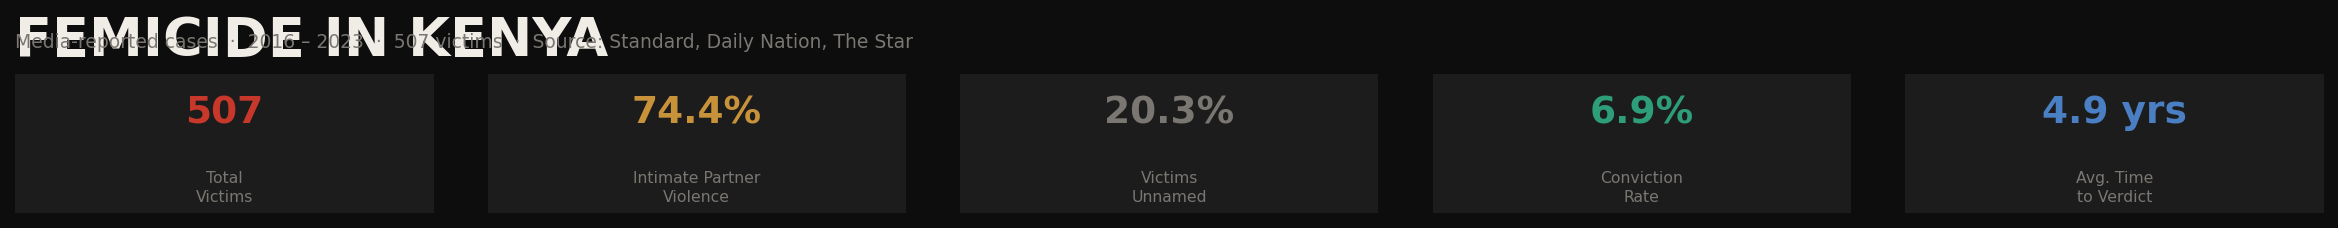

In [ ]:
print('       Fig 1/6 → overview dashboard...')

fig = plt.figure(figsize=(18, 22), facecolor=BG)
fig.suptitle('FEMICIDE IN KENYA', x=0.07, y=0.985,
             fontsize=26, fontweight='bold', color=TEXT, ha='left')
fig.text(0.07, 0.975, 'Media-reported cases  ·  2016 – 2023  ·  507 victims  ·  Source: Standard, Daily Nation, The Star',
         fontsize=9, color=MUTED, ha='left')

# KPI strip
kpis = [
    ('507',  'Total\nVictims',       RED),
    ('74.4%','Intimate Partner\nViolence', AMBER),
    ('20.3%','Victims\nUnnamed',     MUTED),
    ('6.9%', 'Conviction\nRate',     TEAL),
    ('4.9 yrs','Avg. Time\nto Verdict', BLUE),
]
kpi_axes = []
for i, (val, lbl, col) in enumerate(kpis):
    ax = fig.add_axes([0.07 + i*0.175, 0.925, 0.155, 0.042])
    ax.set_facecolor(SURFACE2)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.add_patch(FancyBboxPatch((0,0),1,1, boxstyle='round,pad=0.02',
                                 linewidth=0.8, edgecolor=col,
                                 facecolor=SURFACE2, zorder=0))
    ax.text(0.5, 0.72, val, ha='center', va='center',
            fontsize=18, fontweight='bold', color=col)
    ax.text(0.5, 0.18, lbl, ha='center', va='center',
            fontsize=7.5, color=MUTED, linespacing=1.3)
    kpi_axes.append(ax)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       left=0.07, right=0.97,
                       top=0.91, bottom=0.04,
                       hspace=0.52, wspace=0.35)



In [ ]:
# ── 1a. ANNUAL TREND ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
yr = df['pub_year'].value_counts().sort_index().reset_index()
yr.columns = ['year','count']
yr = yr[yr['year'].between(2016,2023)]
bars = ax1.bar(yr['year'], yr['count'],
               color=[RED if y != 2018 else RED_LIGHT for y in yr['year']],
               width=0.65, zorder=3)
ax1.set_facecolor(SURFACE)
ax1.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax1.set_xlim(2015.3, 2023.7)
ax1.set_ylim(0, 110)
for bar, row in zip(bars, yr.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(row.count), ha='center', va='bottom', fontsize=8, color=TEXT)
ax1.annotate('Peak year\n2018: 95 cases', xy=(2018, 95),
             xytext=(2019.5, 100), fontsize=7.5, color=RED_LIGHT,
             arrowprops=dict(arrowstyle='->', color=RED_LIGHT, lw=0.8))
title(ax1, 'Reported Cases by Year')
subtitle(ax1, 'Based on article publication date  ·  2016–2023')
ax1.set_xticks(yr['year'])
for sp in ax1.spines.values(): sp.set_visible(False)

In [ ]:
# ── 1b. JUSTICE FUNNEL ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(SURFACE)
funnel = [
    ('All cases',       507, '#2A2A2A'),
    ('Reached court',    57, BLUE),
    ('Verdict recorded', 38, AMBER),
    ('Guilty verdict',   35, TEAL),
]
colors_f = ['#333', BLUE, AMBER, TEAL]
max_w = 507
y_pos = [0.75, 0.50, 0.27, 0.05]
heights = [0.18, 0.17, 0.17, 0.17]
for (label, n, col), y, h in zip(funnel, y_pos, heights):
    w = n / max_w
    x_start = (1 - w) / 2
    ax2.add_patch(FancyBboxPatch((x_start, y), w, h,
                                  boxstyle='round,pad=0.01',
                                  facecolor=col, edgecolor='none', alpha=0.9))
    ax2.text(0.5, y + h/2 + 0.01, f'{n}', ha='center', va='center',
             fontsize=13, fontweight='bold', color=TEXT)
    ax2.text(0.5, y + h/2 - 0.04, f'{label}  ({n/507*100:.1f}%)',
             ha='center', va='center', fontsize=7, color=MUTED)
ax2.set_xlim(0,1); ax2.set_ylim(-0.02,1)
ax2.axis('off')
title(ax2, 'The Justice Funnel')
subtitle(ax2, '507 cases → only 35 convictions')



In [ ]:
# ── 1c. COUNTY BAR ───────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cnty = df['county'].value_counts().head(10)
cnames = [c[:12] for c in cnty.index]
alphas = np.linspace(1.0, 0.45, len(cnty))
bars3 = ax3.barh(range(len(cnty)), cnty.values, color=RED, height=0.7)
for bar, a in zip(bars3, alphas):
    bar.set_alpha(a)
for i, (val, name) in enumerate(zip(cnty.values, cnames)):
    ax3.text(val+0.5, i, str(val), va='center', fontsize=7.5, color=TEXT)
ax3.set_yticks(range(len(cnty)))
ax3.set_yticklabels(cnames, fontsize=8)
ax3.invert_yaxis()
ax3.set_facecolor(SURFACE)
ax3.xaxis.grid(True, color=BORDER, linewidth=0.5)
ax3.set_xlim(0, 90)
for sp in ax3.spines.values(): sp.set_visible(False)
title(ax3, 'Top 10 Counties')
subtitle(ax3, 'Cases reported')


In [ ]:
# ── 1d. MODE OF KILLING ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
mok = df['mode_of_killing'].value_counts()
colors_mok = [RED, '#9A3020', '#7A2828', '#6A2A2A', '#5A3030', '#4A3232', '#3A3434', '#2A3636']
bars4 = ax4.barh(range(len(mok)), mok.values, color=colors_mok[:len(mok)], height=0.7)
for i, val in enumerate(mok.values):
    ax4.text(val+0.5, i, str(val), va='center', fontsize=7.5, color=TEXT)
ax4.set_yticks(range(len(mok)))
ax4.set_yticklabels([m[:14] for m in mok.index], fontsize=8)
ax4.invert_yaxis()
ax4.set_facecolor(SURFACE)
ax4.xaxis.grid(True, color=BORDER, linewidth=0.5)
ax4.set_xlim(0, 185)
for sp in ax4.spines.values(): sp.set_visible(False)
title(ax4, 'Mode of Killing')
subtitle(ax4, '441 records  ·  66 missing')


In [ ]:
# ── 1e. SUSPECT RELATIONSHIP ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
rel = df['suspect_relationship'].value_counts()
ipv_cols = {'Husband': AMBER, 'Boyfriend': AMBER, 'Ex-Husband': BLUE, 'Ex-Boyfriend': BLUE}
bar_colors = [ipv_cols.get(r, MUTED) for r in rel.index]
bars5 = ax5.barh(range(len(rel)), rel.values, color=bar_colors, height=0.7)
for i, val in enumerate(rel.values):
    ax5.text(val+0.5, i, str(val), va='center', fontsize=7.5, color=TEXT)
ax5.set_yticks(range(len(rel)))
ax5.set_yticklabels([r[:14] for r in rel.index], fontsize=8)
ax5.invert_yaxis()
ax5.set_facecolor(SURFACE)
ax5.xaxis.grid(True, color=BORDER, linewidth=0.5)
ax5.set_xlim(0, 265)
for sp in ax5.spines.values(): sp.set_visible(False)
p1 = mpatches.Patch(color=AMBER, label='Current partner (IPV)')
p2 = mpatches.Patch(color=BLUE,  label='Former partner')
p3 = mpatches.Patch(color=MUTED, label='Other/Unknown')
ax5.legend(handles=[p1,p2,p3], fontsize=7, loc='lower right', framealpha=0.3)
title(ax5, 'Perpetrator Relationship')
subtitle(ax5, '505 records')


In [ ]:
# ── 1f. VICTIM AGE DISTRIBUTION ──────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
age_g = df['age_group'].value_counts().reindex(['Under 18','18–24','25–34','35–49','50+'])
bars6 = ax6.bar(age_g.index, age_g.values, color=RED, width=0.65)
for bar, a in zip(bars6, [0.5, 0.75, 1.0, 0.7, 0.5]):
    bar.set_alpha(a)
for bar, val in zip(bars6, age_g.values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(int(val)), ha='center', va='bottom', fontsize=8, color=TEXT)
ax6.set_facecolor(SURFACE)
ax6.yaxis.grid(True, color=BORDER, linewidth=0.5)
ax6.set_ylim(0, 130)
for sp in ax6.spines.values(): sp.set_visible(False)
ax6.set_xticklabels(age_g.index, fontsize=8)
title(ax6, 'Victim Age Groups')
subtitle(ax6, 'Based on 312 of 507 records  ·  Median age: 28')

In [ ]:
# ── 1g. MURDER SCENE ─────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
scene = df['murder_scene'].value_counts()
scene_colors = [RED, '#555', '#444', '#3A3A3A', '#333']
bars7 = ax7.bar(scene.index, scene.values,
                 color=scene_colors[:len(scene)], width=0.65)
for bar, val in zip(bars7, scene.values):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', va='bottom', fontsize=8, color=TEXT)
    pct = val/scene.sum()*100
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()//2,
             f'{pct:.0f}%', ha='center', va='center', fontsize=7.5, color=TEXT, alpha=0.8)
ax7.set_facecolor(SURFACE)
ax7.yaxis.grid(True, color=BORDER, linewidth=0.5)
ax7.set_ylim(0, 400)
for sp in ax7.spines.values(): sp.set_visible(False)
ax7.tick_params(axis='x', rotation=10)
title(ax7, 'Location of Killing')
subtitle(ax7, '67% of killings occur at home')



In [ ]:
# ── 1h. TRIGGERING CIRCUMSTANCE ──────────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
circ = df['circumstance_clean'].value_counts().dropna().head(7)
alphas_c = np.linspace(0.9, 0.4, len(circ))
bars8 = ax8.barh(range(len(circ)), circ.values, color=TEAL, height=0.7)
for bar, a in zip(bars8, alphas_c):
    bar.set_alpha(a)
for i, val in enumerate(circ.values):
    ax8.text(val+0.5, i, str(val), va='center', fontsize=7.5, color=TEXT)
ax8.set_yticks(range(len(circ)))
ax8.set_yticklabels([c[:18] for c in circ.index], fontsize=7.5)
ax8.invert_yaxis()
ax8.set_facecolor(SURFACE)
ax8.xaxis.grid(True, color=BORDER, linewidth=0.5)
ax8.set_xlim(0, 210)
for sp in ax8.spines.values(): sp.set_visible(False)
title(ax8, 'Recorded Trigger / Circumstance')
subtitle(ax8, '289 of 507 records  ·  218 missing')


In [ ]:
import matplotlib.pyplot as plt

# Footer
fig.text(0.07, 0.008,
         'Note: This dataset captures media-reported cases only. True femicide prevalence is higher. '
         'Judicial columns cover only 7.5% of cases.',
         fontsize=7.5, color=MUTED, style='italic')

output_filename = '/content/fig1_dashboard.png'
fig.savefig(output_filename, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig)
print(f'  ✓  Saved {output_filename.split("/")[-1]}')

  ✓  Saved fig1_dashboard.png


In [ ]:
print('       Fig 2/6 → justice deep dive...')

fig2, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=BG)
fig2.suptitle('JUSTICE & ACCOUNTABILITY', x=0.06, y=1.02,
              fontsize=18, fontweight='bold', color=TEXT, ha='left')
fig2.text(0.06, 0.98, 'Examining the accountability gap across 507 cases',
          fontsize=9, color=MUTED, ha='left')

# 2a. Verdict donut
ax = axes[0]
ax.set_facecolor(SURFACE)
guilty   = (df['verdict'] == 'Guilty').sum()
not_g    = (df['verdict'] == 'Not Guilty').sum()
no_v     = df['has_verdict'].value_counts()[False]
sizes  = [guilty, not_g, no_v]
clrs   = [TEAL, RED, '#333']
labels = [f'Guilty\n{guilty}', f'Not Guilty\n{not_g}', f'No Verdict\n{no_v}']
wedges, texts = ax.pie(sizes, colors=clrs, startangle=90,
                       wedgeprops={'width': 0.55, 'edgecolor': BG, 'linewidth': 1.5},
                       pctdistance=0.82)
ax.text(0, 0, f'{guilty/507*100:.1f}%\nConviction\nRate', ha='center', va='center',
        fontsize=11, fontweight='bold', color=TEAL, linespacing=1.4)
p1 = mpatches.Patch(color=TEAL, label=f'Guilty ({guilty})')
p2 = mpatches.Patch(color=RED,  label=f'Not Guilty ({not_g})')
p3 = mpatches.Patch(color='#333', label=f'No verdict ({no_v})')
ax.legend(handles=[p1,p2,p3], fontsize=8, loc='lower center',
          bbox_to_anchor=(0.5,-0.12), ncol=1)
ax.set_title('Verdict Outcomes\n507 cases', fontsize=10, color=TEXT, fontweight='bold')

# 2b. Years to verdict distribution
ax = axes[1]
ax.set_facecolor(SURFACE)
ytv = df['years_to_verdict'].dropna()
ax.hist(ytv, bins=10, color=AMBER, alpha=0.85, edgecolor=BG, linewidth=0.5, zorder=3)
ax.axvline(ytv.mean(),   color=RED,  lw=1.5, linestyle='--', label=f'Mean: {ytv.mean():.1f} yrs')
ax.axvline(ytv.median(), color=TEAL, lw=1.5, linestyle='--', label=f'Median: {ytv.median():.1f} yrs')
ax.set_xlabel('Years to verdict', color=MUTED)
ax.set_ylabel('Number of cases', color=MUTED)
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax.legend(fontsize=8)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title('Time from Report to Verdict\n34 cases with data', fontsize=10, color=TEXT, fontweight='bold')

# 2c. Sentence lengths
ax = axes[2]
ax.set_facecolor(SURFACE)
sentences = df['years_of_sentence'].dropna().sort_values()
y_pos = range(len(sentences))
ax.barh(y_pos, sentences.values, color=BLUE, height=0.7, alpha=0.85)
ax.axvline(sentences.mean(), color=AMBER, lw=1.5, linestyle='--',
           label=f'Mean: {sentences.mean():.1f} yrs')
ax.set_yticks([])
ax.set_xlabel('Years of sentence', color=MUTED)
ax.xaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
for sp in ax.spines.values(): sp.set_visible(False)
ax.legend(fontsize=8)
ax.set_title(f'Custodial Sentences Handed Down\n{len(sentences)} cases with sentence data',
             fontsize=10, color=TEXT, fontweight='bold')
for i, val in enumerate(sentences.values):
    ax.text(val+0.2, i, f'{val:.0f} yrs', va='center', fontsize=7.5, color=TEXT)

plt.tight_layout(pad=2)
output_filename = '/content/fig2_justice.png'
fig2.savefig(output_filename, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig2)
print(f'  ✓  Saved {output_filename.split("/")[-1]}')

       Fig 2/6 → justice deep dive...
  ✓  Saved fig2_justice.png


In [ ]:
print('       Fig 3/6 → IPV deep dive...')

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 6), facecolor=BG)
fig3.suptitle('INTIMATE PARTNER VIOLENCE', x=0.06, y=1.02,
              fontsize=18, fontweight='bold', color=TEXT, ha='left')
fig3.text(0.06, 0.98, '74.4% of femicides are perpetrated by current or former intimate partners',
          fontsize=9, color=MUTED, ha='left')

# 3a. IPV vs Non-IPV by year
ax = axes3[0]
ax.set_facecolor(SURFACE)
yr_ipv = df.groupby(['pub_year','is_ipv']).size().unstack(fill_value=0)
yr_ipv = yr_ipv[(yr_ipv.index >= 2016) & (yr_ipv.index <= 2023)]
years = yr_ipv.index.astype(int)
ax.bar(years, yr_ipv[True],  label='IPV',     color=AMBER, width=0.6, alpha=0.9, zorder=3)
ax.bar(years, yr_ipv[False], label='Non-IPV', color='#555', width=0.6,
       bottom=yr_ipv[True], alpha=0.8, zorder=3)
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax.legend(fontsize=8)
ax.set_xticks(years); ax.set_xticklabels(years, rotation=45, fontsize=7.5)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title('IPV vs Non-IPV by Year\nStacked counts', fontsize=10, color=TEXT, fontweight='bold')

# 3b. IPV breakdown by relationship type
ax = axes3[1]
ax.set_facecolor(SURFACE)
ipv_rel = df[df['is_ipv']]['suspect_relationship'].value_counts()
bars = ax.bar(ipv_rel.index, ipv_rel.values,
              color=[AMBER, '#D4701A', BLUE, '#2A6094'], width=0.65, zorder=3)
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
for bar, val in zip(bars, ipv_rel.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            str(val), ha='center', va='bottom', fontsize=9, color=TEXT)
    pct = val/df['is_ipv'].sum()*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()//2,
            f'{pct:.0f}%', ha='center', va='center', fontsize=8, color=TEXT)
for sp in ax.spines.values(): sp.set_visible(False)
ax.tick_params(axis='x', labelsize=8)
ax.set_title('IPV Breakdown by Relationship\n377 IPV cases', fontsize=10, color=TEXT, fontweight='bold')

# 3c. IPV by murder scene
ax = axes3[2]
ax.set_facecolor(SURFACE)
scene_ipv = df.groupby(['murder_scene','is_ipv']).size().unstack(fill_value=0)
scene_ipv = scene_ipv.sort_values(True, ascending=False)
x = range(len(scene_ipv))
w = 0.38
bars_i = ax.bar([i-w/2 for i in x], scene_ipv[True],  width=w, color=AMBER, label='IPV', alpha=0.9)
bars_n = ax.bar([i+w/2 for i in x], scene_ipv[False], width=w, color='#555', label='Non-IPV', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(scene_ipv.index, rotation=20, ha='right', fontsize=8)
ax.yaxis.grid(True, color=BORDER, linewidth=0.5)
ax.legend(fontsize=8)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title('IPV vs Non-IPV by Crime Scene\n', fontsize=10, color=TEXT, fontweight='bold')

plt.tight_layout(pad=2)
output_filename = '/content/fig3_ipv.png'
fig3.savefig(output_filename, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig3)
print(f'  ✓  Saved {output_filename.split("/")[-1]}')

       Fig 3/6 → IPV deep dive...
  ✓  Saved fig3_ipv.png


In [ ]:
print('       Fig 4/6 → geographic deep dive...')

fig4, axes4 = plt.subplots(1, 2, figsize=(16, 8), facecolor=BG)
fig4.suptitle('GEOGRAPHIC DISTRIBUTION', x=0.06, y=1.01,
              fontsize=18, fontweight='bold', color=TEXT, ha='left')
fig4.text(0.06, 0.98, 'County-level breakdown of 507 cases across Kenya',
          fontsize=9, color=MUTED, ha='left')

# 4a. All counties with ≥2 cases
ax = axes4[0]
ax.set_facecolor(SURFACE)
all_cnty = df['county'].value_counts()
all_cnty = all_cnty[all_cnty >= 2]
cmap = plt.cm.Reds
norm = plt.Normalize(all_cnty.min(), all_cnty.max())
bar_colors = [cmap(norm(v)) for v in all_cnty.values]
bars = ax.barh(range(len(all_cnty)), all_cnty.values,
               color=bar_colors, height=0.75)
ax.set_yticks(range(len(all_cnty)))
ax.set_yticklabels(all_cnty.index, fontsize=7.5)
ax.invert_yaxis()
for i, val in enumerate(all_cnty.values):
    ax.text(val+0.2, i, str(val), va='center', fontsize=7, color=TEXT)
ax.xaxis.grid(True, color=BORDER, linewidth=0.5)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xlim(0, 90)
ax.set_title('All Counties with ≥2 cases\n(Counties with <2 omitted)',
             fontsize=10, color=TEXT, fontweight='bold')

# 4b. Top 10 counties — mode of killing breakdown
ax = axes4[1]
ax.set_facecolor(SURFACE)
top10 = df['county'].value_counts().head(10).index
df_top = df[df['county'].isin(top10)]
pivot = df_top.groupby(['county','mode_of_killing']).size().unstack(fill_value=0)
pivot = pivot.loc[top10[::-1]]  # reverse for horizontal
mode_colors = {
    'Stabbed':        RED,
    'Blunt Force':    '#9A3020',
    'Hacked':         '#7A2828',
    'Strangled':      BLUE,
    'Shot':           AMBER,
    'Sexual Assault': '#AA5599',
    'Burned':         '#B87040',
    'Other':          '#555',
}
bottom = np.zeros(len(pivot))
for mode in pivot.columns:
    col = mode_colors.get(mode, '#666')
    ax.barh(range(len(pivot)), pivot[mode].values,
            left=bottom, color=col, label=mode, height=0.72, alpha=0.9)
    bottom += pivot[mode].values
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.xaxis.grid(True, color=BORDER, linewidth=0.5)
for sp in ax.spines.values(): sp.set_visible(False)
ax.legend(fontsize=7, loc='lower right', framealpha=0.2, ncol=2)
ax.set_title('Top 10 Counties — Mode of Killing\nStacked by method', fontsize=10, color=TEXT, fontweight='bold')

plt.tight_layout(pad=2)
output_filename = 'fig4_geography.png'
fig4.savefig(f'/content/{output_filename}', dpi=150,
                bbox_inches='tight', facecolor=BG)
plt.close(fig4)
print(f'  ✓  Saved {output_filename}')

       Fig 4/6 → geographic deep dive...
  ✓  Saved fig4_geography.png


In [ ]:
print('       Fig 5/6 → victim profile...')

fig5, axes5 = plt.subplots(1, 3, figsize=(16, 6), facecolor=BG)
fig5.suptitle('VICTIM PROFILE', x=0.06, y=1.02,
              fontsize=18, fontweight='bold', color=TEXT, ha='left')
fig5.text(0.06, 0.98, 'Who the victims are — age, identification, and femicide type',
          fontsize=9, color=MUTED, ha='left')

# 5a. Age distribution histogram
ax = axes5[0]
ax.set_facecolor(SURFACE)
age_data = df['age'].dropna()
ax.hist(age_data, bins=20, color=RED, alpha=0.85, edgecolor=BG, linewidth=0.5, zorder=3)
ax.axvline(age_data.mean(),   color=AMBER, lw=1.5, ls='--', label=f'Mean: {age_data.mean():.1f}')
ax.axvline(age_data.median(), color=TEAL,  lw=1.5, ls='--', label=f'Median: {age_data.median():.1f}')
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax.legend(fontsize=8)
ax.set_xlabel('Age', color=MUTED)
ax.set_ylabel('Number of victims', color=MUTED)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title(f'Age at Time of Death\n{len(age_data)} of 507 records', fontsize=10, color=TEXT, fontweight='bold')

# 5b. Named vs unnamed by year
ax = axes5[1]
ax.set_facecolor(SURFACE)
yr_named = df.groupby(['pub_year','victim_identified']).size().unstack(fill_value=0)
yr_named = yr_named[(yr_named.index >= 2016) & (yr_named.index <= 2023)]
years = yr_named.index.astype(int)
ax.bar(years, yr_named[True],  label='Named',   color=TEAL,  width=0.65, alpha=0.9, zorder=3)
ax.bar(years, yr_named[False], label='Unnamed', color='#555', width=0.65,
       bottom=yr_named[True], alpha=0.85, zorder=3)
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax.legend(fontsize=8)
ax.set_xticks(years); ax.set_xticklabels(years, rotation=45, fontsize=7.5)
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_title('Named vs Unnamed Victims by Year\n103 unnamed (20.3%)', fontsize=10, color=TEXT, fontweight='bold')

# 5c. Femicide type + age group heatmap
ax = axes5[2]
ax.set_facecolor(SURFACE)
pivot2 = df.groupby(['type_of_femicide','age_group']).size().unstack(fill_value=0)
pivot2 = pivot2[['Under 18','18–24','25–34','35–49','50+']]
im = ax.imshow(pivot2.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels(pivot2.columns, fontsize=8)
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index, fontsize=9)
for i in range(pivot2.shape[0]):
    for j in range(pivot2.shape[1]):
        v = pivot2.values[i,j]
        ax.text(j, i, str(v), ha='center', va='center',
                fontsize=10, fontweight='bold',
                color=TEXT if v > pivot2.values.max()//2 else MUTED)
ax.set_title('Femicide Type × Age Group\nHeatmap (cell = case count)', fontsize=10, color=TEXT, fontweight='bold')
for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout(pad=2)
output_filename = '/content/fig5_victim_profile.png'
fig5.savefig(output_filename, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig5)
print(f'  ✓  Saved {output_filename.split("/")[-1]}')

       Fig 5/6 → victim profile...
  ✓  Saved fig5_victim_profile.png


In [ ]:
print('       Fig 6/6 → monthly heatmap...')

fig6, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
fig6.suptitle('MONTHLY REPORTING HEATMAP', x=0.06, y=1.02,
              fontsize=18, fontweight='bold', color=TEXT, ha='left')
fig6.text(0.06, 0.98, 'Number of cases by year and month of article publication',
          fontsize=9, color=MUTED, ha='left')

heat = df.groupby(['pub_year','pub_month']).size().unstack(fill_value=0)
heat = heat.loc[heat.index.dropna()]
heat = heat[sorted(heat.columns)]
heat.index = heat.index.astype(int)

im = ax.imshow(heat.values, cmap='Reds', aspect='auto', interpolation='nearest')
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(range(12))
ax.set_xticklabels(months, fontsize=9)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=9)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i,j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    fontsize=8, fontweight='bold' if v > 10 else 'normal',
                    color=TEXT if v > heat.values.max()*0.5 else MUTED)
cbar = fig6.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=MUTED)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=MUTED, fontsize=7.5)
cbar.set_label('Cases', color=MUTED, fontsize=8)
ax.set_facecolor(SURFACE)
for sp in ax.spines.values(): sp.set_visible(False)

plt.tight_layout()
output_filename = '/content/fig6_heatmap.png'
fig6.savefig(output_filename, dpi=150, bbox_inches='tight', facecolor=BG)
plt.close(fig6)
print(f'  ✓  Saved {output_filename.split("/")[-1]}')

       Fig 6/6 → monthly heatmap...
  ✓  Saved fig6_heatmap.png


In [ ]:
print('\n[5/6]  SAVING CLEANED DATA')
df.to_csv('/content/femicide_clean_final.csv', index=False)
print(f'       femicide_clean_final.csv  →  {df.shape[0]} rows × {df.shape[1]} cols')


[5/6]  SAVING CLEANED DATA
       femicide_clean_final.csv  →  507 rows × 30 cols


In [ ]:
print('\n[6/6]  FINAL SUMMARY')
print()
print('  ╔══════════════════════════════════════════════════════════╗')
print('  ║         FEMICIDE IN KENYA — KEY FINDINGS               ║')
print('  ╠══════════════════════════════════════════════════════════╣')
print(f'  ║  Total cases:              {len(df):<30}║')
print(f'  ║  Date range:               2016–2023                     ║')
print(f'  ║  Counties represented:     {df["county"].nunique():<30}║')
print(f'  ║  Unnamed victims:          103 (20.3%)                   ║')
print(f'  ║  IPV share:                {df["is_ipv"].sum()} ({df["is_ipv"].mean()*100:.1f}%)                    ║')
print(f'  ║  Most common method:       Stabbing (154 cases)          ║')
print(f'  ║  Most dangerous location:  Home (67%)                    ║')
print(f'  ║  Highest burden county:    Nairobi (75 cases)            ║')
print(f'  ║  Cases reaching court:     57 (11.2%)                    ║')
print(f'  ║  Conviction rate:          6.9% (35 of 507)              ║')
print(f'  ║  Avg. years to verdict:    {df["years_to_verdict"].mean():.1f} years                      ║')
print(f'  ╚══════════════════════════════════════════════════════════╝')
print()
print('  Output files:')
print('    femicide_clean_final.csv')
print('    fig1_dashboard.png')
print('    fig2_justice.png')
print('    fig3_ipv.png')
print('    fig4_geography.png')
print('    fig5_victim_profile.png')
print('    fig6_heatmap.png')
print()
print('  Analysis complete.')



[6/6]  FINAL SUMMARY

  ╔══════════════════════════════════════════════════════════╗
  ║         FEMICIDE IN KENYA — KEY FINDINGS               ║
  ╠══════════════════════════════════════════════════════════╣
  ║  Total cases:              507                           ║
  ║  Date range:               2016–2023                     ║
  ║  Counties represented:     45                            ║
  ║  Unnamed victims:          103 (20.3%)                   ║
  ║  IPV share:                377 (74.4%)                    ║
  ║  Most common method:       Stabbing (154 cases)          ║
  ║  Most dangerous location:  Home (67%)                    ║
  ║  Highest burden county:    Nairobi (75 cases)            ║
  ║  Cases reaching court:     57 (11.2%)                    ║
  ║  Conviction rate:          6.9% (35 of 507)              ║
  ║  Avg. years to verdict:    4.9 years                      ║
  ╚══════════════════════════════════════════════════════════╝

  Output files:
    femicide_cl

### View and Download Generated Visuals
The visualizations were saved to the `/content/` directory in your Colab environment. You can display them here and download them to your local machine using the code below.


--- Displaying and providing download link for: fig1_dashboard.png ---


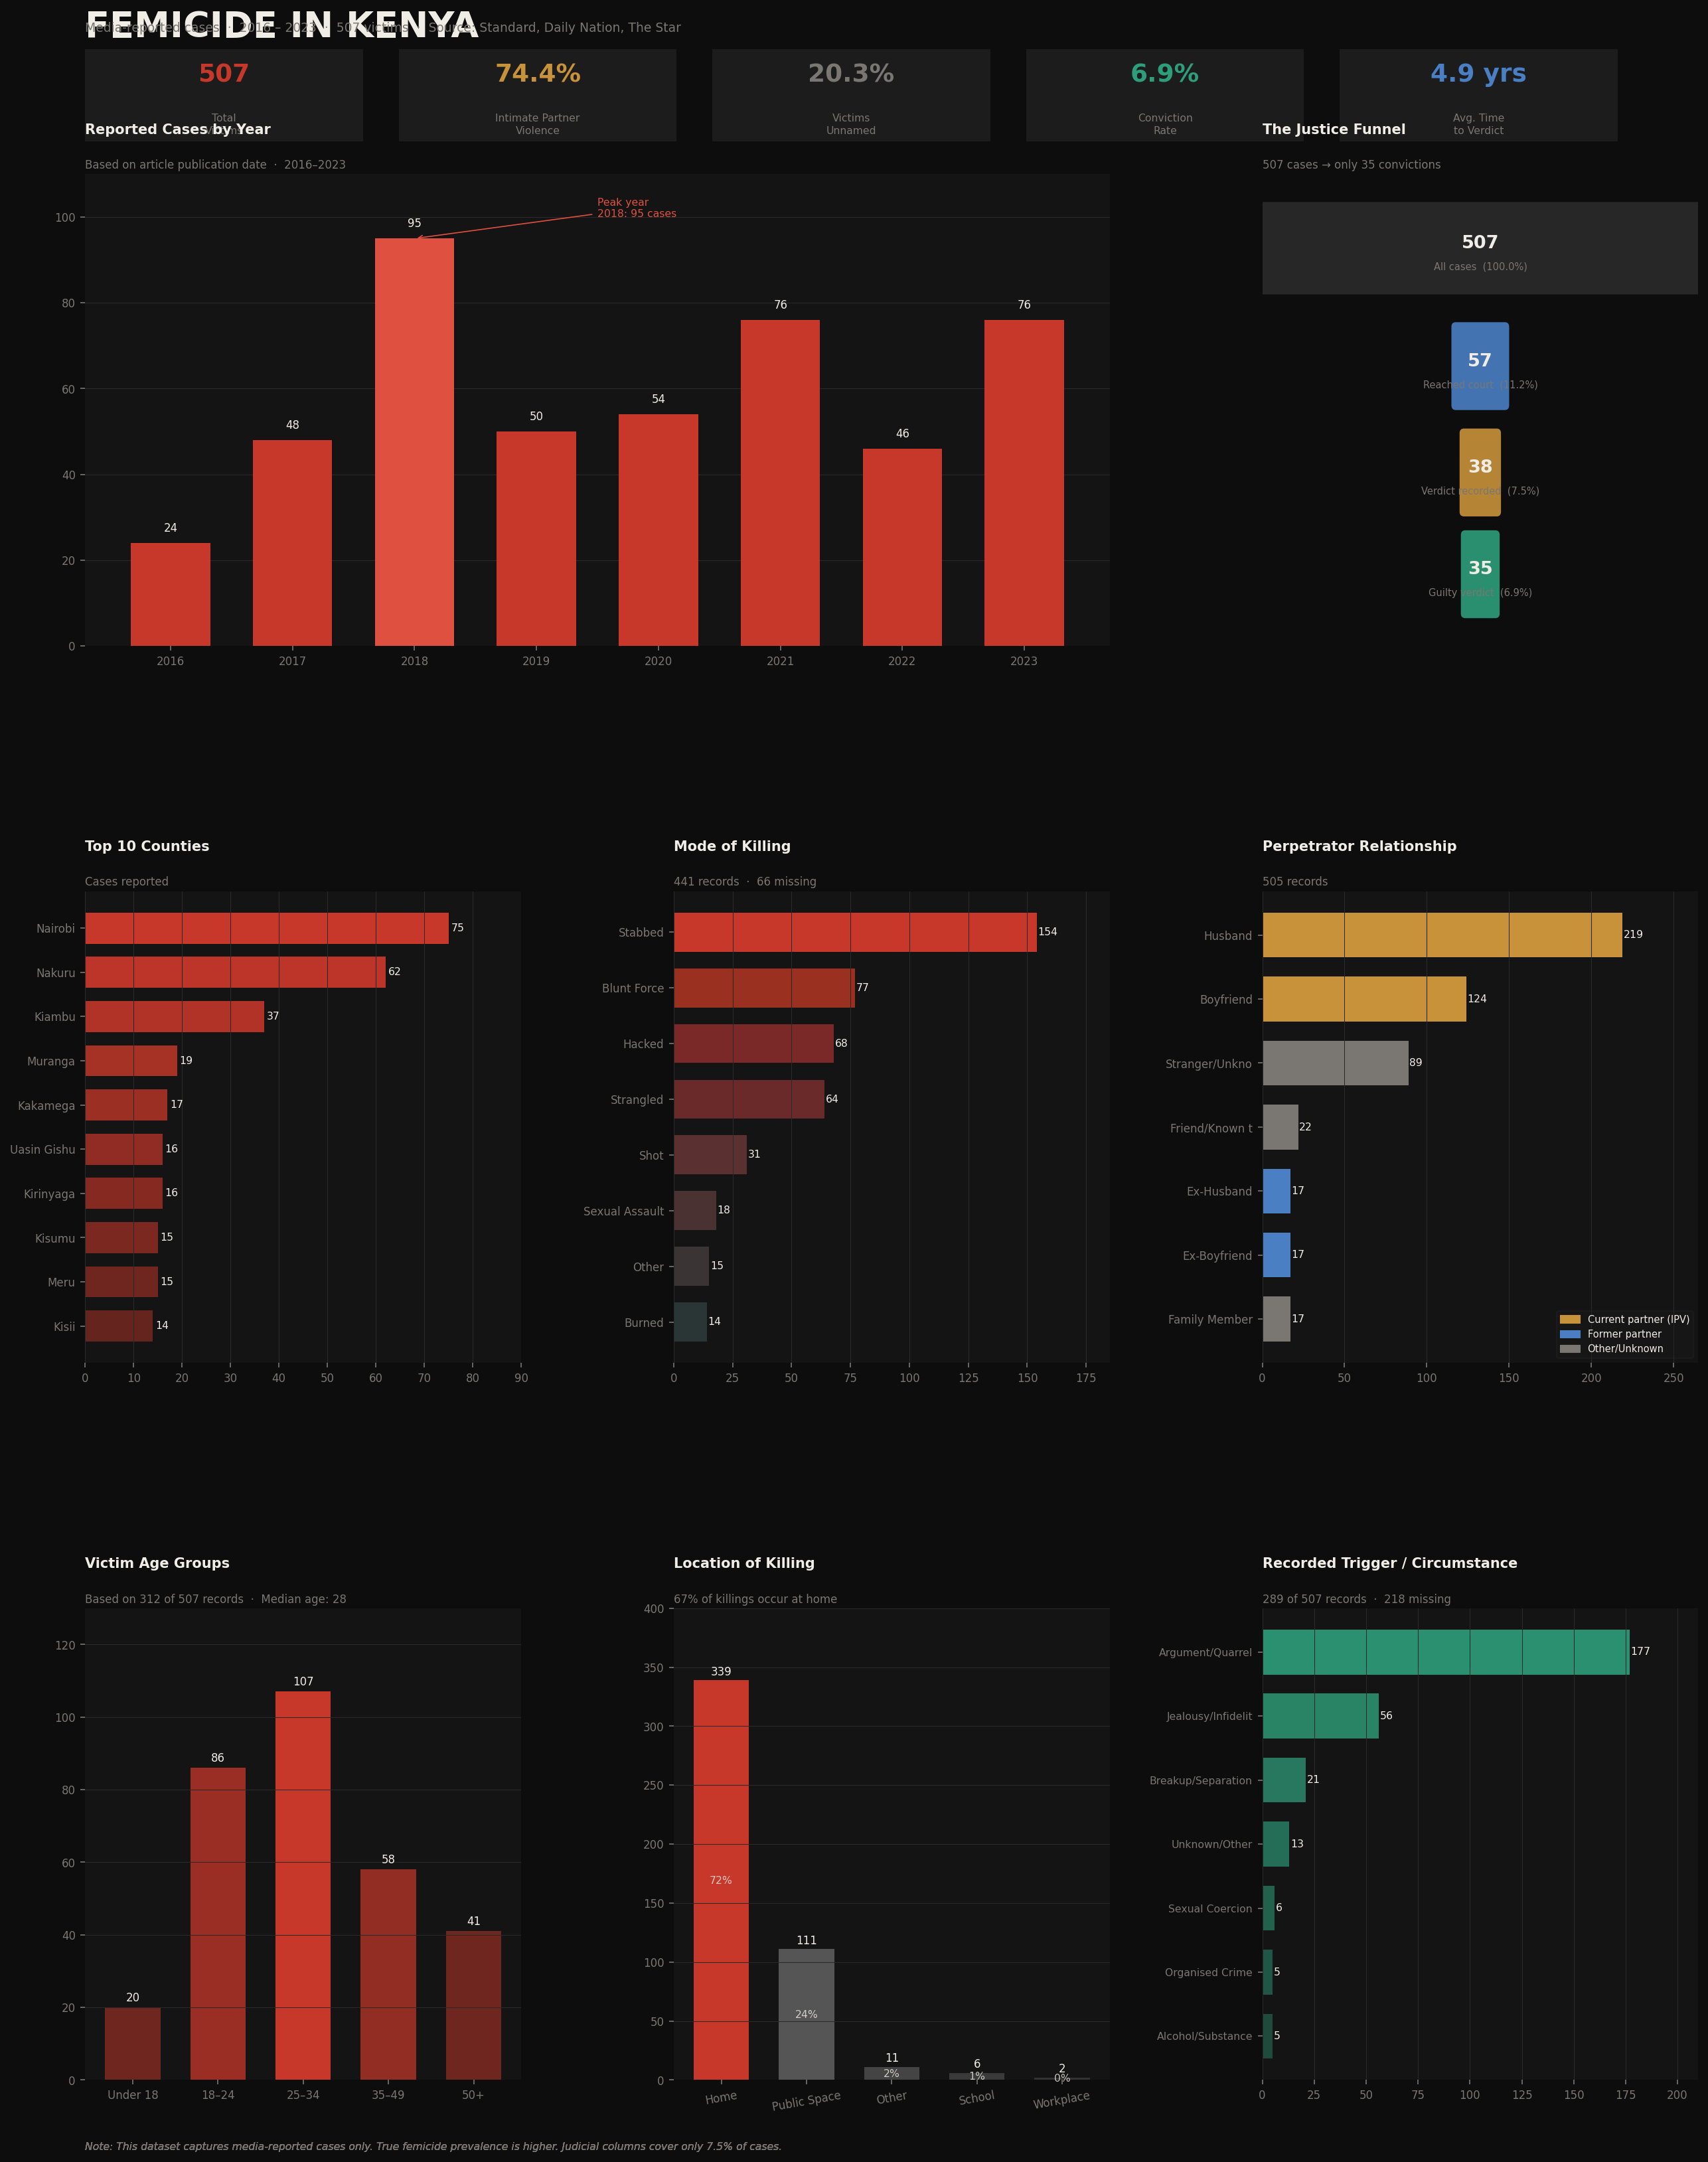

/content/fig1_dashboard.png


--- Displaying and providing download link for: fig2_justice.png ---


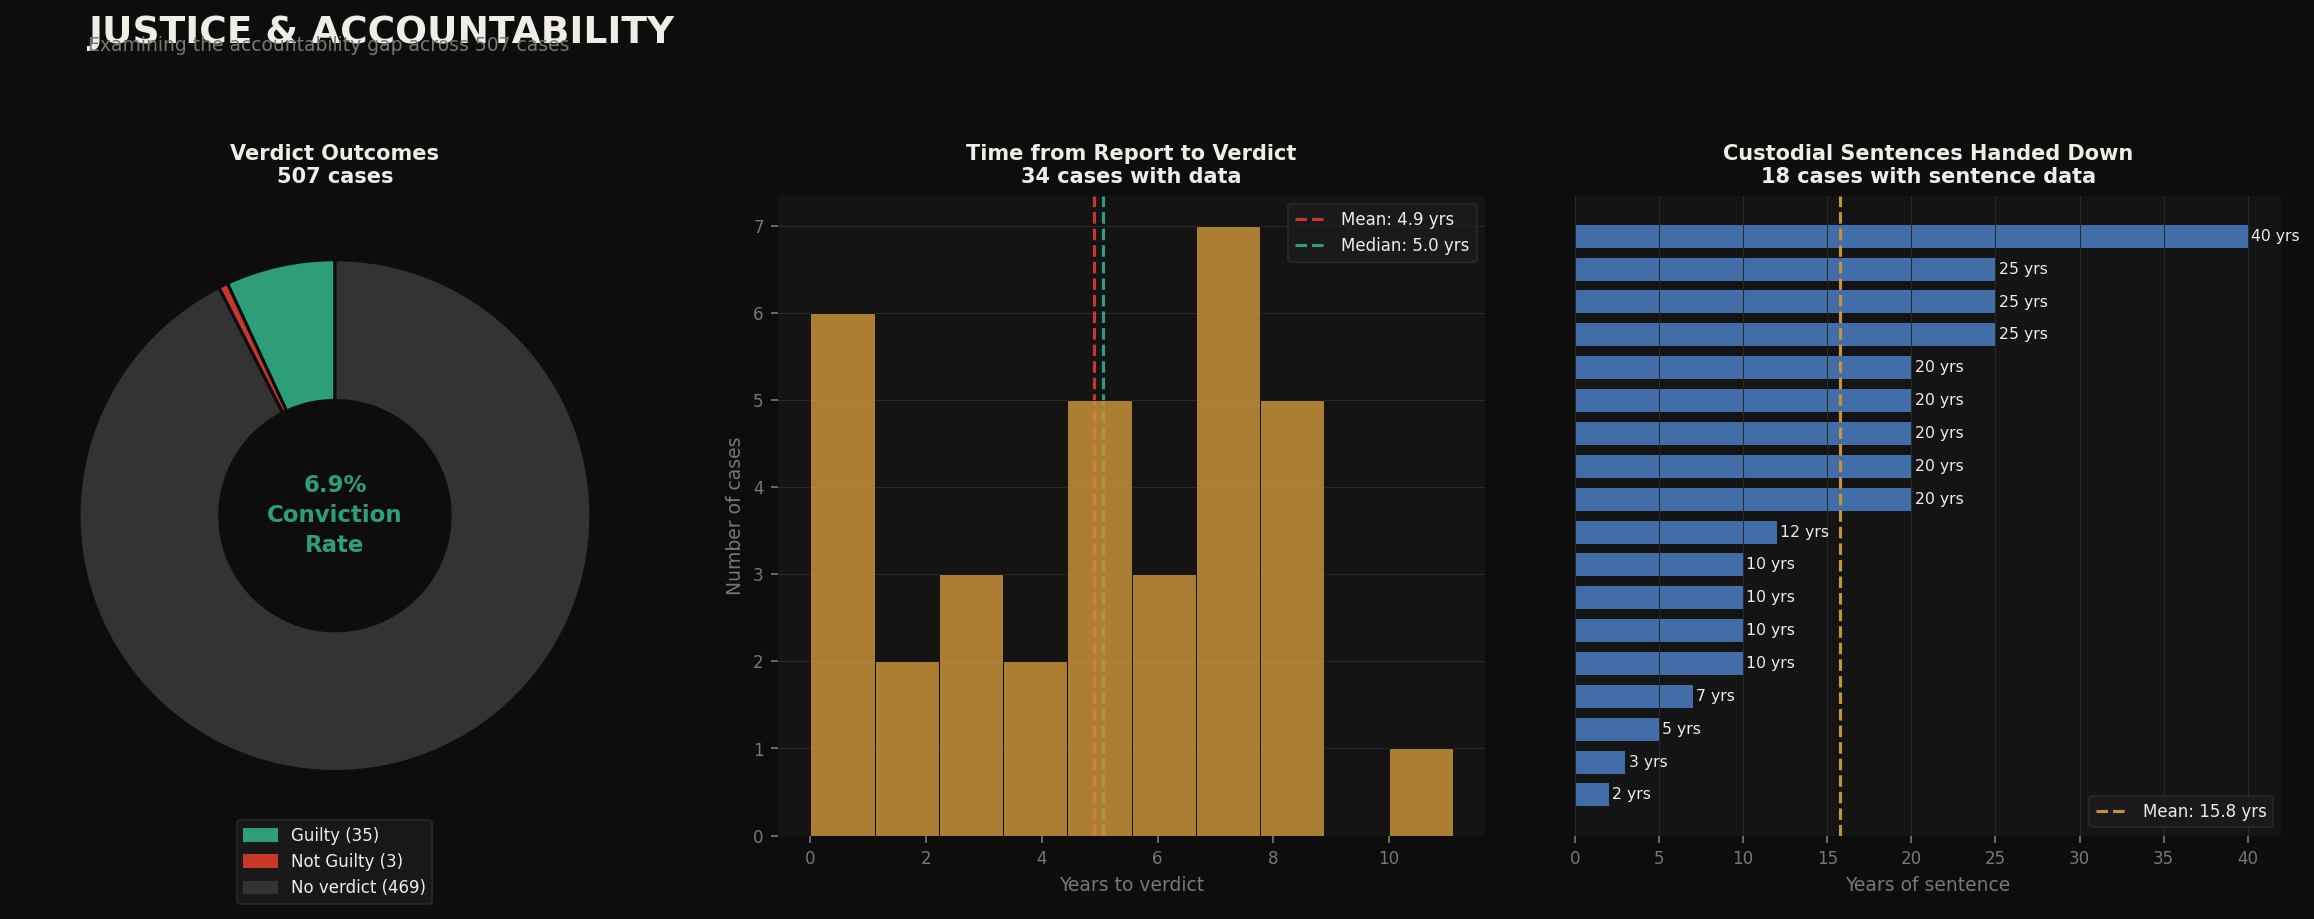

/content/fig2_justice.png


--- Displaying and providing download link for: fig3_ipv.png ---


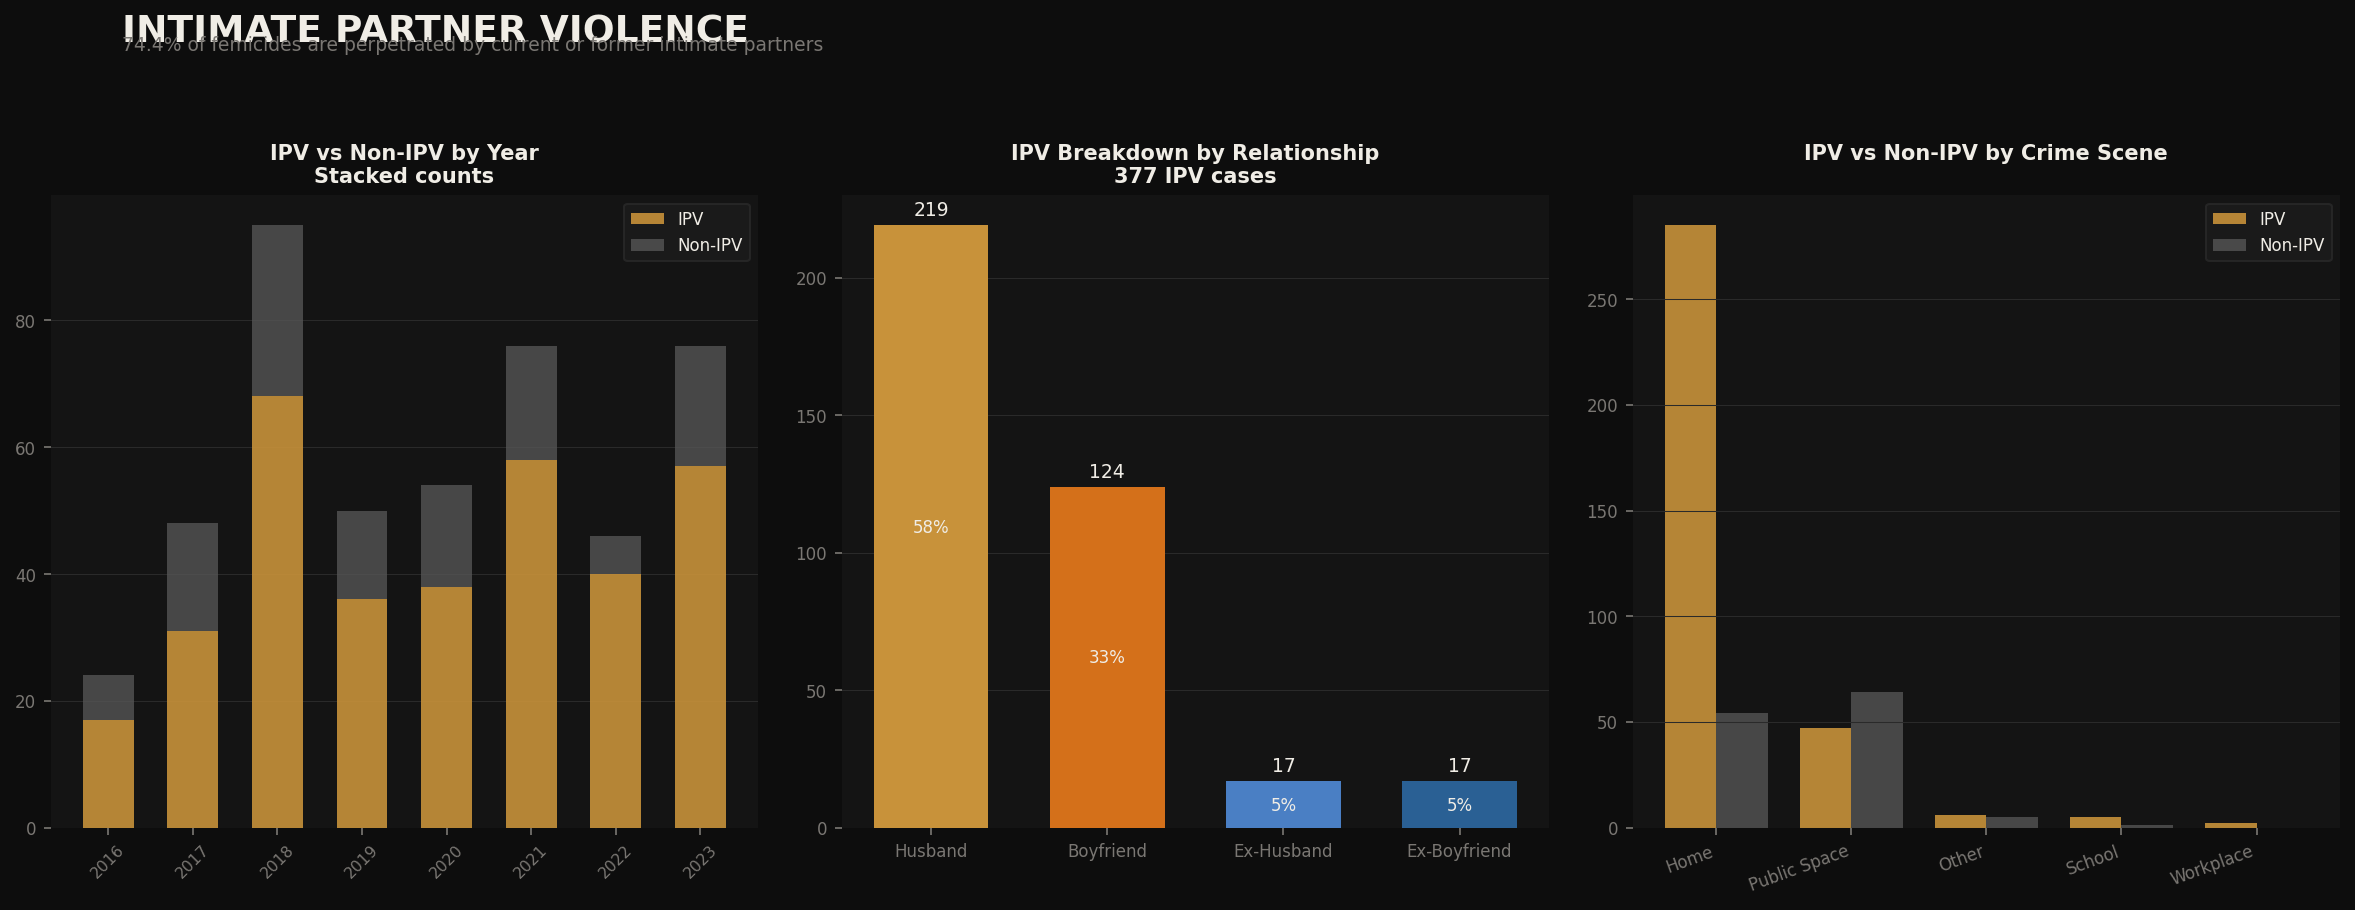

/content/fig3_ipv.png


--- Displaying and providing download link for: fig4_geography.png ---


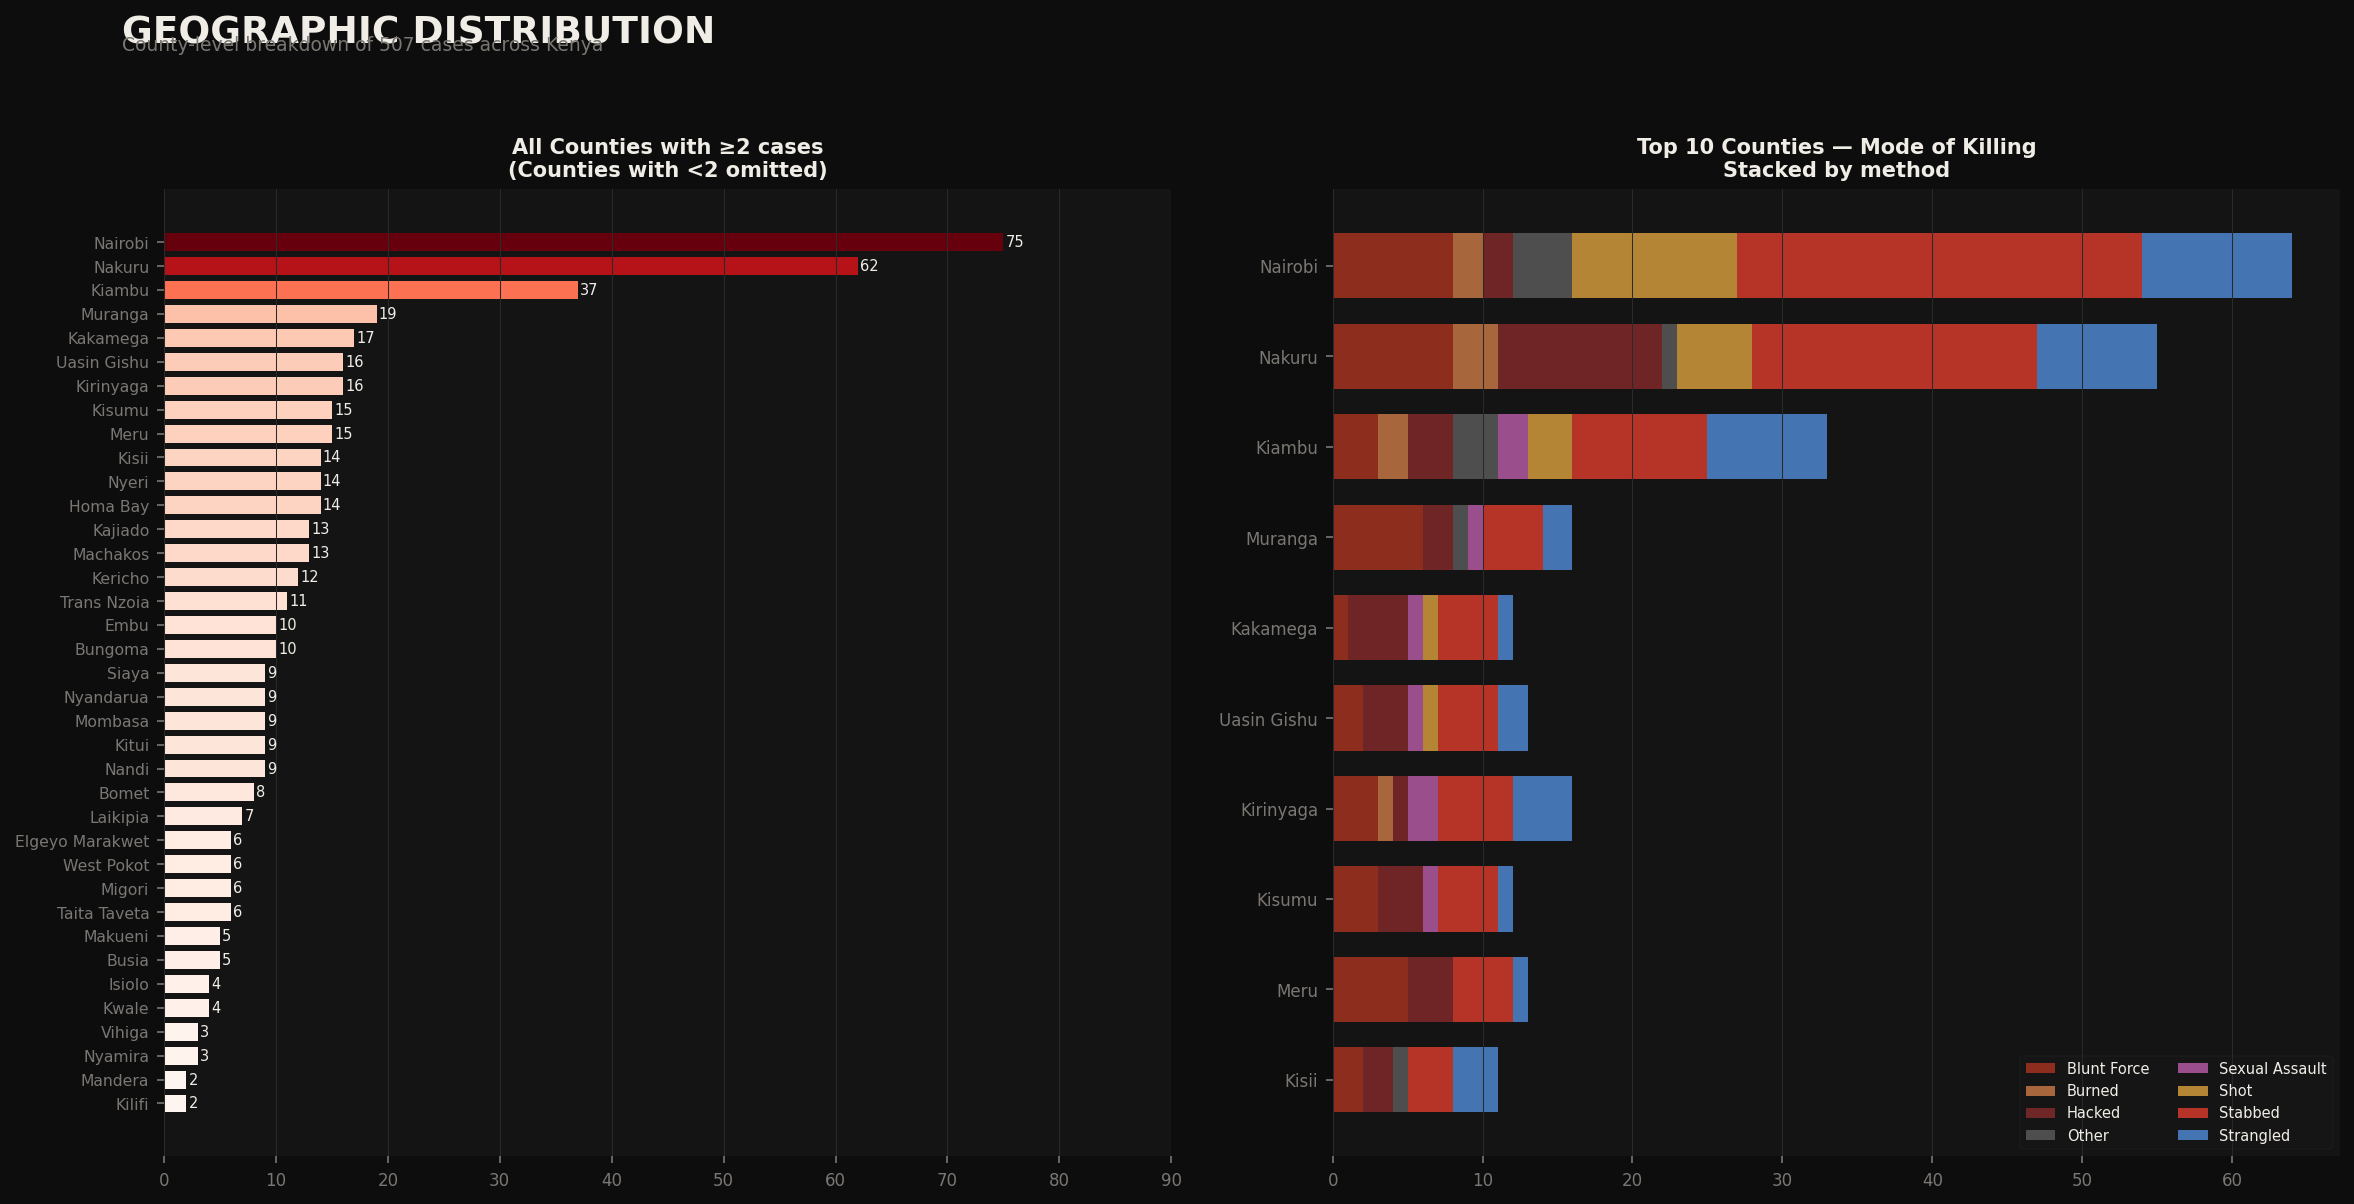

/content/fig4_geography.png


--- Displaying and providing download link for: fig5_victim_profile.png ---


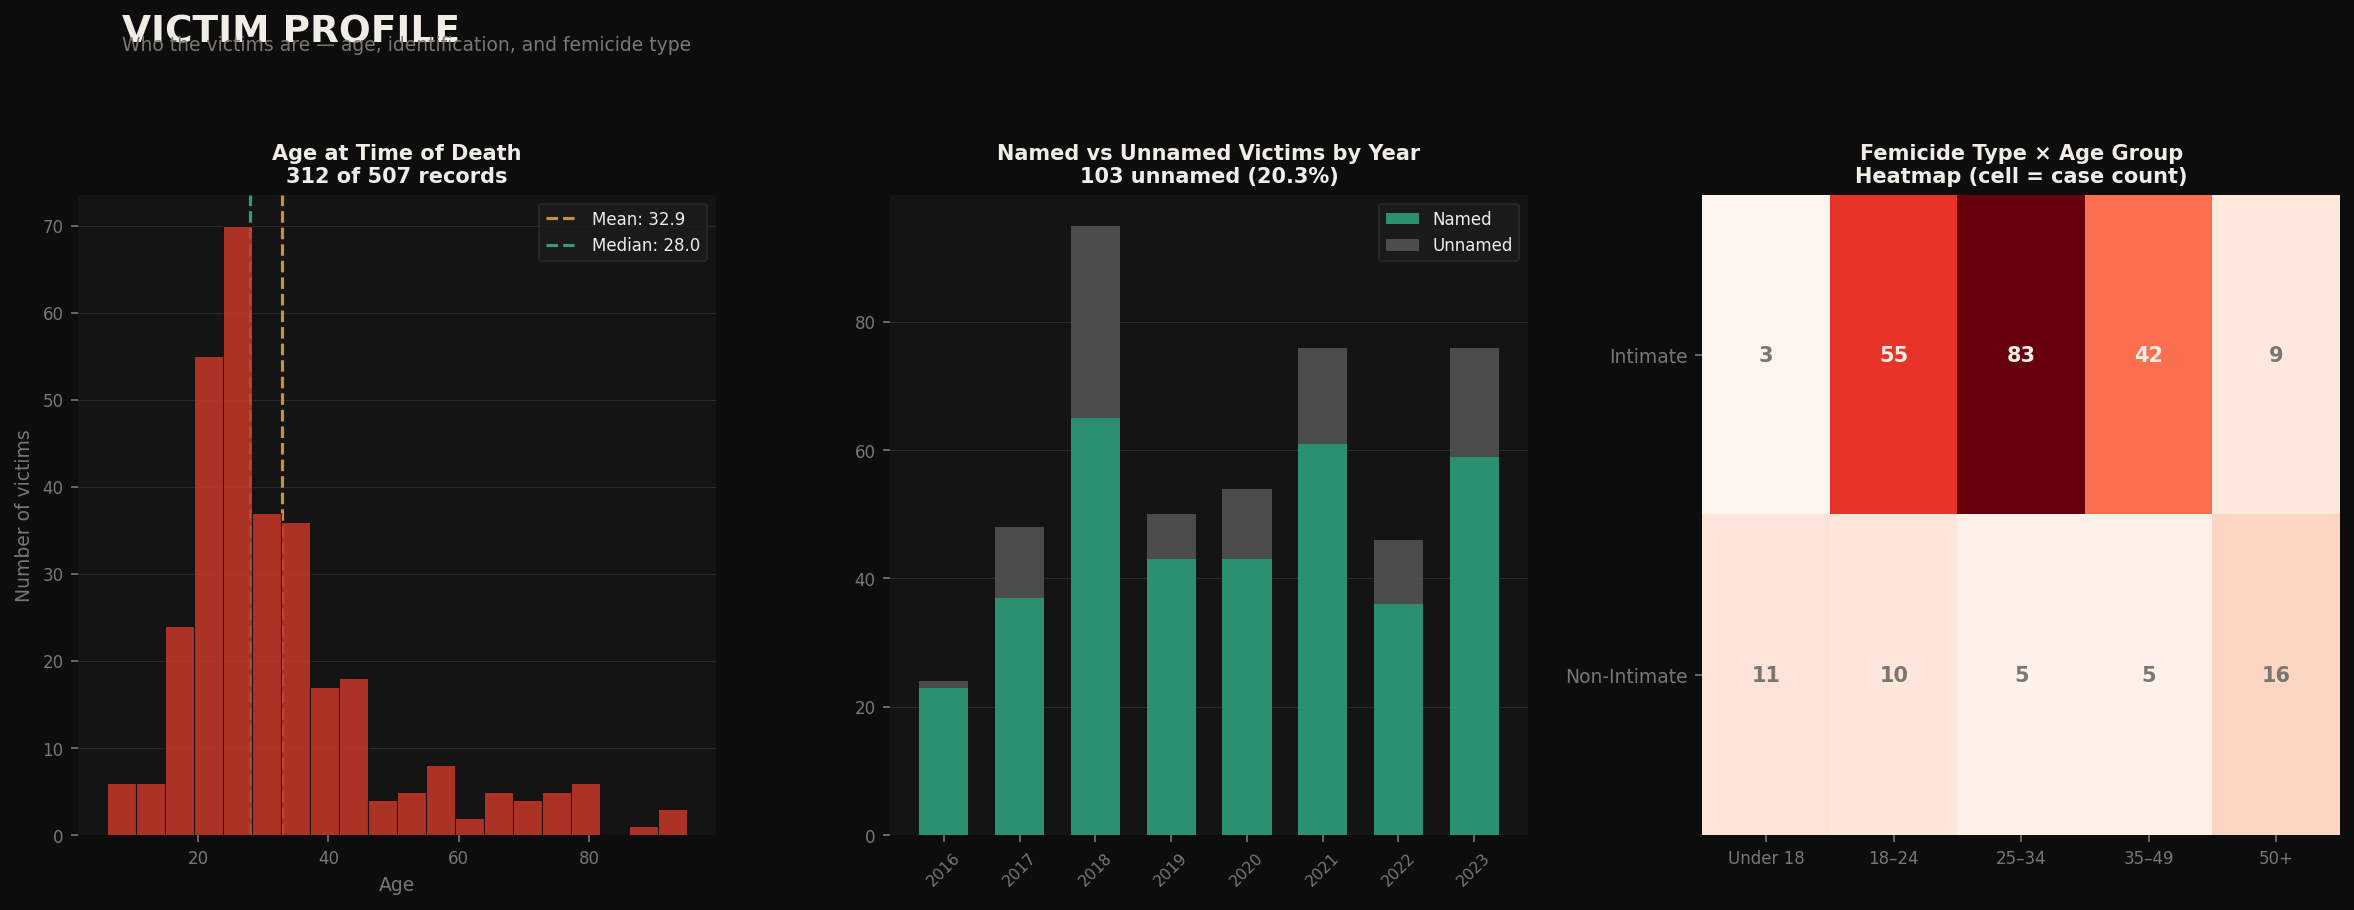

/content/fig5_victim_profile.png


--- Displaying and providing download link for: fig6_heatmap.png ---


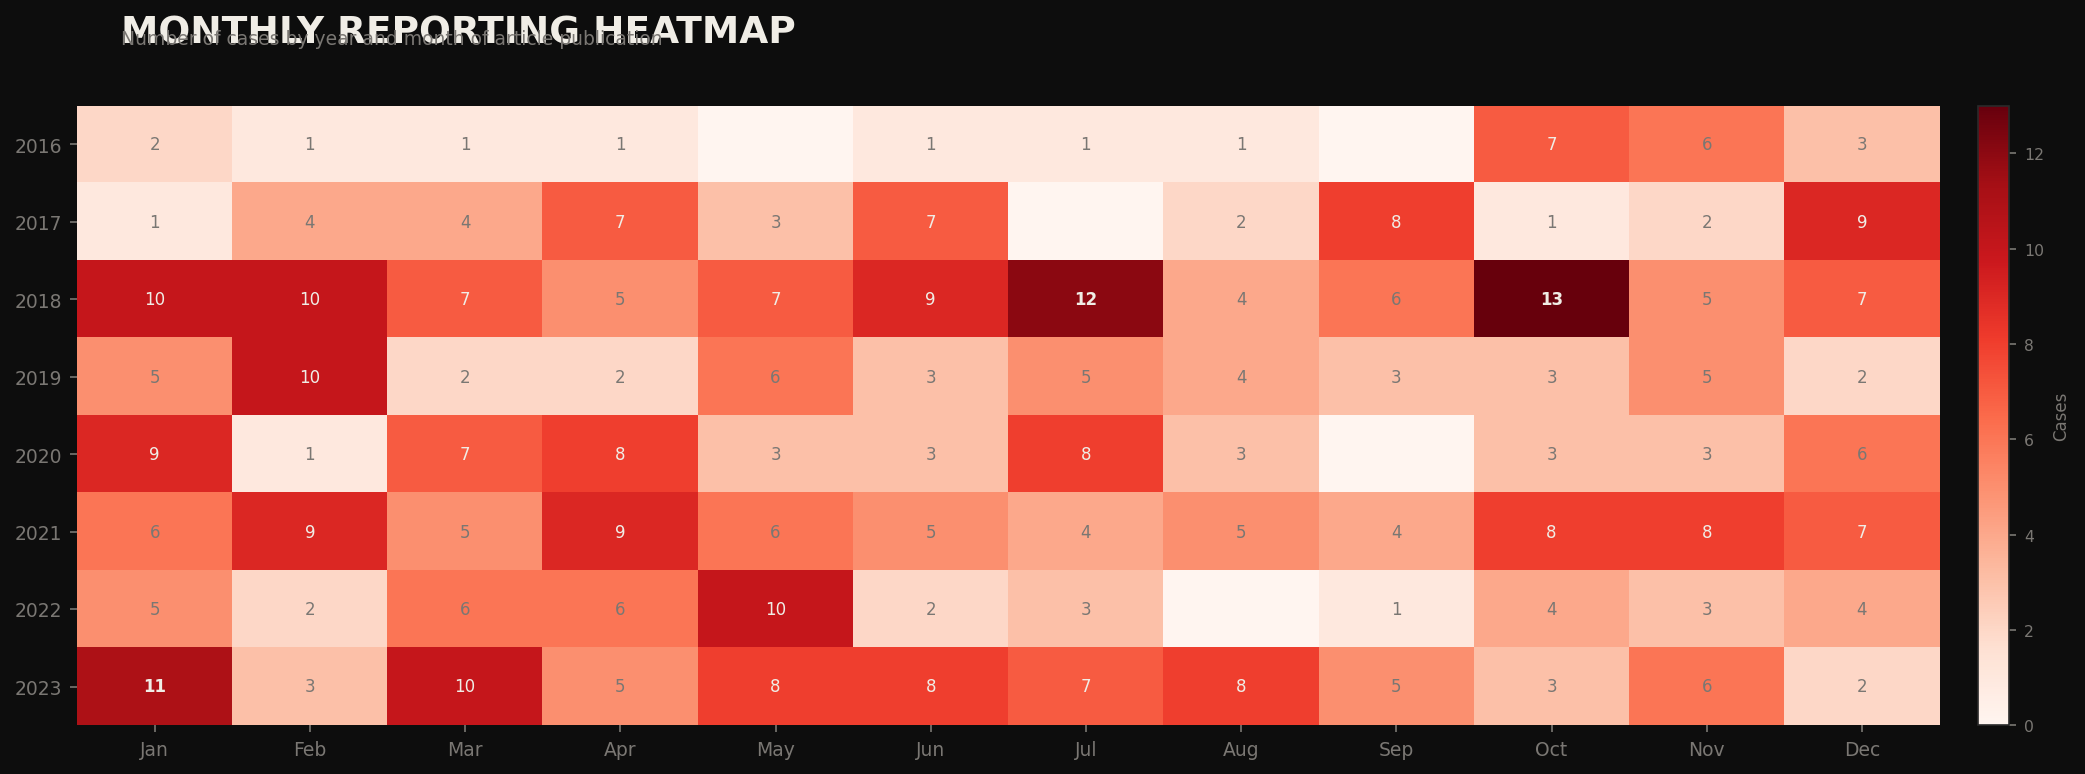

/content/fig6_heatmap.png

In [ ]:
from IPython.display import Image, FileLink

image_files = [
    'fig1_dashboard.png',
    'fig2_justice.png',
    'fig3_ipv.png',
    'fig4_geography.png',
    'fig5_victim_profile.png',
    'fig6_heatmap.png'
]

for img_file in image_files:
    print(f'\n--- Displaying and providing download link for: {img_file} ---')
    display(Image(filename=f'/content/{img_file}'))
    display(FileLink(f'/content/{img_file}'))
